# Vorarbeiten

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("db_bereinigt_final.csv")

In [3]:
'''
# Daten aus Datenbank einlesen

from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()
db_password = os.getenv("DB_PASSWORD")

# Verbindungsdaten anpassen
db_user = 'neondb_owner'
db_host = 'ep-summer-band-aselkm9n-pooler.c-4.eu-central-1.aws.neon.tech'
db_port = '5432'
db_name = 'neondb'

# Engine erstellen
engine = create_engine(f'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}')

# SQL-Query definieren und Daten in den DataFrame laden
query = "SELECT * FROM ashrae_consolidado"
df = pd.read_sql(query, con=engine)

# Erste Zeilen zur Kontrolle anzeigen
display(df.head())
'''

'\n# Daten aus Datenbank einlesen\n\nfrom sqlalchemy import create_engine\nimport os\nfrom dotenv import load_dotenv\n\nload_dotenv()\ndb_password = os.getenv("DB_PASSWORD")\n\n# Verbindungsdaten anpassen\ndb_user = \'neondb_owner\'\ndb_host = \'ep-summer-band-aselkm9n-pooler.c-4.eu-central-1.aws.neon.tech\'\ndb_port = \'5432\'\ndb_name = \'neondb\'\n\n# Engine erstellen\nengine = create_engine(f\'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}\')\n\n# SQL-Query definieren und Daten in den DataFrame laden\nquery = "SELECT * FROM ashrae_consolidado"\ndf = pd.read_sql(query, con=engine)\n\n# Erste Zeilen zur Kontrolle anzeigen\ndisplay(df.head())\n'

In [4]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [5]:
df

,building_id,contributor,region,country,city,latitude,longitude,climate,building_type,cooling_type,...,door,heater,outdoor_air_temperature,outdoor_relative_humidity,standard_effective_temperature,predicted_mean_vote,predicted_percentage_dissatisfied,calculated_predicted_mean_vote,calculated_predicted_percentage_dissatisfied,climate_zone
0,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,28.1,0.50,10.2,0.38,8.0,Temperate
1,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,27.2,0.40,8.4,0.40,8.4,Temperate
2,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,24.8,-0.07,5.1,-0.07,5.1,Temperate
3,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,25.5,0.31,7.0,0.14,5.4,Temperate
4,1,David Rowe,oceania,australia,sydney,-33.868820,151.209295,humid subtropical,office,mixed mode,...,NaN,NaN,15.86,99.1,26.0,0.05,5.0,-0.06,5.1,Temperate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109028,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical
109029,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical
109030,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical
109031,809,Harimi Djamila,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,others,air conditioned,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tropical


In [6]:
# Target Kleidungsisolationswert
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'clothing_ensemble_insulation']] #   Basis 0,13 MAE
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']]   # MAE 0,12
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'metabolic_rate', 'climate', 'clothing_ensemble_insulation']]
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'metabolic_rate', 'climate', 'cooling_type', 'clothing_ensemble_insulation']]

df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'building_type', 'air_speed', 'metabolic_rate', 'cooling_type', 'clothing_ensemble_insulation']]

# Vergleich mit DBSCAN und Regression
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']]

In [7]:
df_ml_clo['cooling_type'] = df_ml_clo['cooling_type'].replace(['unknown', 'Unknown', 'UNKNOWN', 'nan', 'None'], np.nan)
df_ml_clo

C:\Users\User\AppData\Local\Temp\ipykernel_26880\157953021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml_clo['cooling_type'] = df_ml_clo['cooling_type'].replace(['unknown', 'Unknown', 'UNKNOWN', 'nan', 'None'], np.nan)


,outdoor_air_temperature,air_temperature,relative_humidity,season,building_type,air_speed,metabolic_rate,cooling_type,clothing_ensemble_insulation
0,15.86,22.3,61.0,winter,office,0.03,1.706485,mixed mode,0.95
1,15.86,23.0,59.0,winter,office,0.08,1.109215,mixed mode,1.07
2,15.86,22.0,61.0,winter,office,0.04,1.211604,mixed mode,0.88
3,15.86,23.2,58.0,winter,office,0.03,1.774744,mixed mode,0.59
4,15.86,22.2,62.0,winter,office,0.15,1.484642,mixed mode,0.83
...,...,...,...,...,...,...,...,...,...
109028,NaN,27.6,64.0,hot/wet,others,NaN,1.100000,air conditioned,0.64
109029,NaN,28.3,66.0,hot/wet,others,NaN,1.100000,air conditioned,0.79
109030,NaN,28.3,66.0,hot/wet,others,NaN,1.100000,air conditioned,0.62
109031,NaN,28.3,66.0,hot/wet,others,NaN,1.200000,air conditioned,0.57


In [8]:
df_ml_clo_clean = df_ml_clo.dropna()

In [9]:
df_ml_clo_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47584 entries, 0 to 107852
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   outdoor_air_temperature       47584 non-null  float64
 1   air_temperature               47584 non-null  float64
 2   relative_humidity             47584 non-null  float64
 3   season                        47584 non-null  object 
 4   building_type                 47584 non-null  object 
 5   air_speed                     47584 non-null  float64
 6   metabolic_rate                47584 non-null  float64
 7   cooling_type                  47584 non-null  object 
 8   clothing_ensemble_insulation  47584 non-null  float64
dtypes: float64(6), object(3)
memory usage: 3.6+ MB


# Isolation Forest

In [10]:
# Anders als beim DBSCAN, wo Dichtewolken analysiert werden, können und sollten kategorische Features beim Isolation Forest im Modell bleiben
# Eine Skalierung der kontinuierlichen Features ist nicht erforderlich, somit unterscheidet sich der Isolation Forest stark von DBSCAN!

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import OneHotEncoder, TargetEncoder

X = df_ml_clo_clean.drop(columns=['clothing_ensemble_insulation'])
y = df_ml_clo_clean['clothing_ensemble_insulation']


 # durch den one-hot-encoder entstehen 52 Spalten, grundsätzlich kein Problem für den isolation forest
 # deshalb werden jedoch kategorische Anomalien leichter gefunden als die physikalischen (Verwässerungsproblem)
 # deshalb entweder alternativ den target-encoder verwenden (elegantere Lösung)
 # oder max_features=0.5 im Algorithmus verwenden
categorial_features = [
    "season",
    "building_type",
    "cooling_type",
]

# Target encoder sind keine gute Wahl in Isolation Forest Modellen - sehr riskant, gerade da hier daraus die relevantesten Features entstehen
#targenc_features = [
##    "climate",
#    "country"
#    ]

feature_names = df_ml_clo_clean.drop(columns=['clothing_ensemble_insulation']).columns.tolist()

##columns_to_scale = ['air_speed', 'metabolic_rate']
columns_to_scale = ['air_speed', 'outdoor_air_temperature']
other_columns = [col for col in feature_names if col not in columns_to_scale]

# Train-Test-Split # nur sinnvoll für Vorbereitung der Regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   


# ColumnTransformer für gezielte Skalierung
preprocessor = ColumnTransformer(
    transformers=[
        #('num_scaler', StandardScaler(), columns_to_scale),
        ('power_transform', PowerTransformer(method='yeo-johnson'), columns_to_scale),
        ('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features),   # sparse_output für GradientBoostingRegrressor # alternativ wäre ein ordinal encoding denkbar

#        ('target_encoder', TargetEncoder(smooth="auto", cv=5, random_state=42), targenc_features)  # hier wird y mit berücksichtigt, deshalb wird y unten benötigt im fit!!!! Alternativ wäre es wahrscheinlich sinnvoll die Anzahl der Klimazonen zu reduzieren und einen anderen encoder zu verwenden
    ],
    remainder='passthrough', # Verbleibende Spalten bleiben unverändert
    verbose_feature_names_out=False
)

# Für Vergleich mit DBSCAN - Pipeline überbrücken, da nur noch ein Set vorhanden ist und das nur numerischen Werte hat
#preprocessor = ColumnTransformer(transformers=[], remainder='passthrough')


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

'''
Anomalieerkennung braucht eigentlich keine vierer Aufteilung. Hier nur die Aufteilung in Train und Testset, um ggf. das Modell der Regression zu modifizieren.
Außerdem wurden in der Pipeline Encoder verwendet, deshalb wird beim fit nicht nur X, sondern auch y benötigt.
Normalerweise würde man einen kompletten dataframe in fit_predict werfen!
'''

# Pipeline definieren
# 'preprocessor' ist hier der bereits existierender ColumnTransformer
anomaly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('anomaly_detector', IsolationForest(
        n_estimators=100,

        # contamination ergibt aus nachfolgender Graphik!!!
        #contamination=0.02, # Schätzung: 2% Ausreißer
        #contamination=0.00001,  # Minert, muss zwischen 0 und 0.5 liegen offenes Intervall, also exklusive der Randwerte
        #contamination=0.5, # Maxwert
#        contamination=0.013295, # Ausknick bei Kurve ermittelt

        contamination=0.00793669939449497,
        #contamination=0.00897, # Ausknick bei Kurve ermittelt für Train Test Split
        #contamination=0.01, # für dbscan-Vergleich
        #contamination='auto',  #   für ersten Durchlauf zum Ermitteln des richtigen Wertes
        random_state=42,
        n_jobs=-1
    ))
])

# Pipeline fitten und direkt Vorhersagen generieren
# Hinweis: Da IsolationForest kein y benötigt, übergeben wir nur X_train
# predictions = anomaly_pipeline.fit_predict(X_train)   # Wäre okay ohne target encoding, da hier aber target encoding ist y_train doch erforderlich

# Block angepasst wegen target_encoding
anomaly_pipeline.fit(X_train, y_train)  # y_train wird für das Trainieren ignoriert!!!!    x_train wird über pipeline encoded, y wird aber in der Pipeline benötigt!!!
X_train_preprocessed = anomaly_pipeline.named_steps['preprocessor'].transform(X_train)  # für spätere plots und zum predicten, xtrain wird umgewandelt und in der Form als dataframe abgespeichert. Es entssteht ein rein numerischer dataframe.

anomaly_scores = anomaly_pipeline.decision_function(X_train)

X_train_analyzed = X_train.copy()
X_train_analyzed['Anomalie_Score'] = anomaly_scores

X_train_analyzed['Anomalie_Label'] = anomaly_pipeline.predict(X_train)

anomalien = X_train_analyzed[X_train_analyzed['Anomalie_Label'] == -1]
print(f"Es wurden {len(anomalien)} Anomalien in den Daten identifiziert.")


Es wurden 303 Anomalien in den Daten identifiziert.


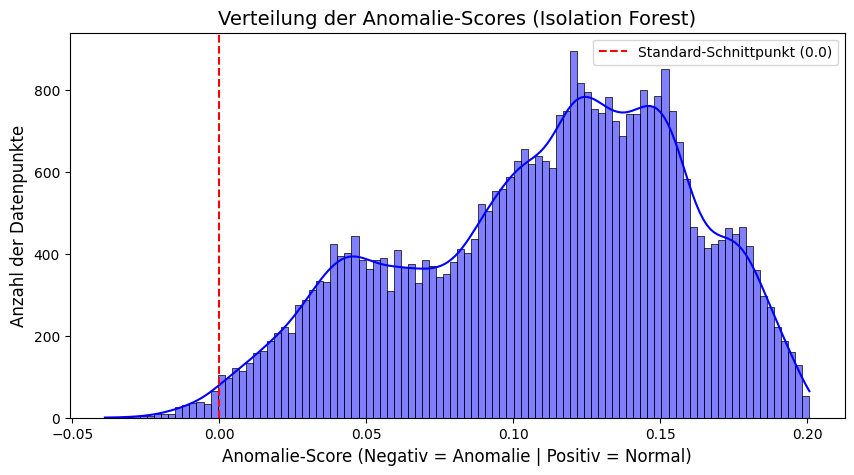

In [12]:
# Plot Verteilung der Anomalie-Scores

plt.figure(figsize=(10, 5))
# Ein Histogramm mit einer Dichtelinie (KDE) zeichnen
sns.histplot(anomaly_scores, bins=100, kde=True, color='blue')

# Titel und Achsenbeschriftung
plt.title("Verteilung der Anomalie-Scores (Isolation Forest)", fontsize=14)
plt.xlabel("Anomalie-Score (Negativ = Anomalie | Positiv = Normal)", fontsize=12)
plt.ylabel("Anzahl der Datenpunkte", fontsize=12)

# Eine rote Linie bei 0.0 zeichnen (Der Standard-Schwellenwert von Scikit-Learn)
plt.axvline(x=0, color='red', linestyle='--', label='Standard-Schnittpunkt (0.0)')
plt.legend()
plt.show()

# Diese Graphik muss erstmal durch einen ersten Durchlauf des "isolation forest" erstellt werden. Danach kann man einen contamination-Wert bestimmen.

In [13]:
contamination_wert = (anomaly_scores < -0.088).mean()
#contamination_wert = (anomaly_scores < -0.095).mean()   # hier Wert eintragen aus Diagramm
#contamination_wert = (anomaly_scores < -0.12).mean()   # hier Wert eintragen aus Diagramm
print(f"contamination_wert oben für den estimator: {contamination_wert}")


contamination_wert oben für den estimator: 0.0


Vorgehensweise: 
- Estimator mit auto durchlaufen lassen
- Scoreplot erstellen
- über den x Wert im Plot die Linie verschieben, bis sie die Anomalie abschneidet
- contamination_wert über die Gleichung ermitteln
- contamination_wert im Estimator eintragen
- Plot mit x=0 prüfen, ob das Diagramm den Schnitt richtig setzt

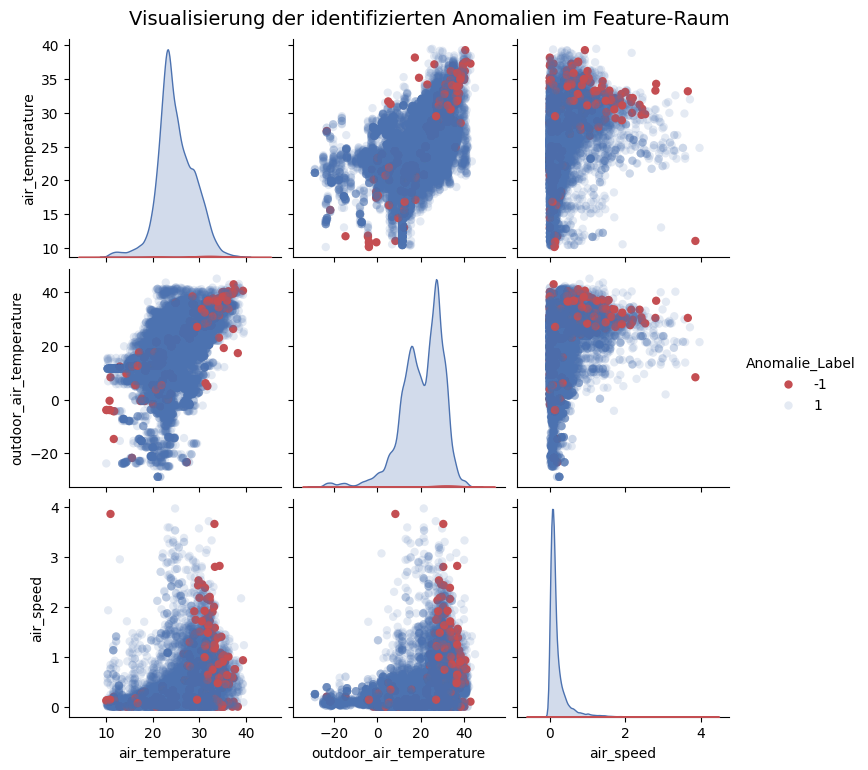

In [14]:
# anomalien darstellen

features_zum_plotten = ['air_temperature', 'outdoor_air_temperature', 'air_speed']

transparente_palette = {
     1: '#4C72B026',  # Normal: Stark transparent (Alpha ~ 0.15)
    -1: '#C44E52FF'   # Anomalie: Voll deckend (Alpha = 1.0)
}

sns.pairplot(
    data=X_train_analyzed,
    hue='Anomalie_Label',                  
    vars=features_zum_plotten,     
    palette=transparente_palette,  # Unsere neue Palette mit eingebautem Alpha
    plot_kws={'edgecolor': 'none'}, # WICHTIG: Das globale 'alpha' hier löschen!
    diag_kind='kde'                
)

plt.suptitle("Visualisierung der identifizierten Anomalien im Feature-Raum", y=1.02, fontsize=14)
plt.show()

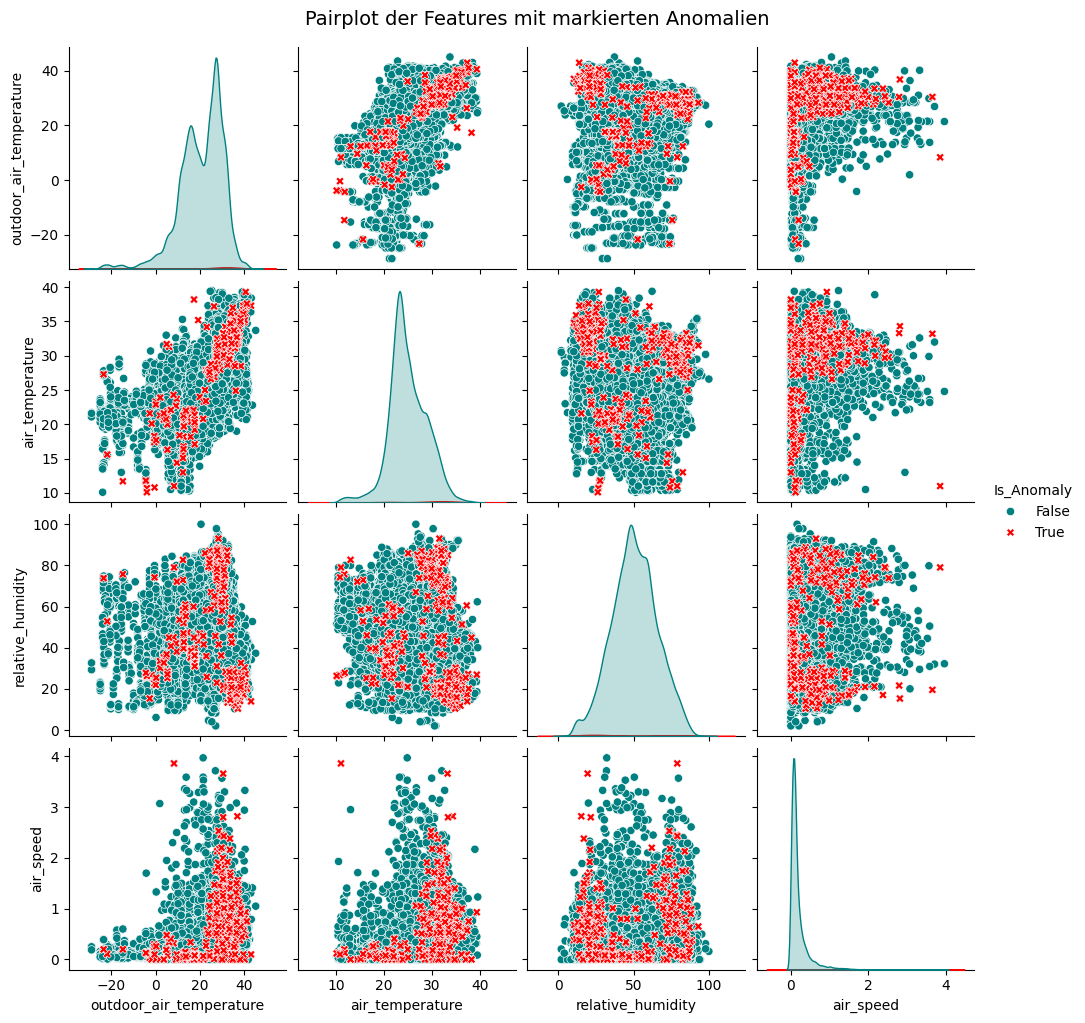

In [15]:
# Pairplot Anomalien

df_plot = X_train_analyzed.copy()
df_plot["Is_Anomaly"] = df_plot["Anomalie_Label"].map({-1: True, 1: False})

# Anomalien sortiert, damit die roten Punkte nicht überdeckt werden
df_plot = df_plot.sort_values(by="Is_Anomaly", ascending=True)

features_zum_plotten = [
    'outdoor_air_temperature', 
    'air_temperature', 
    'relative_humidity', 
    'air_speed', 
    ##'metabolic_rate', 
]


transparente_palette = {
    False: '#008080FF',
    True: '#FF0000FF'  
}

# 3. Den Pairplot aufbauen
sns.pairplot(
    data=df_plot,
    hue='Is_Anomaly',           
    vars=features_zum_plotten,      
    palette=transparente_palette,   
    markers=['o', 'X'],             
    diag_kind='kde'                 
)

plt.suptitle('Pairplot der Features mit markierten Anomalien', y=1.02, fontsize=14)
plt.show()


In [16]:
# Die 10 extremsten Anomalien anzeigen
top_anomalien = anomalien.sort_values(by='Anomalie_Score').head(10)
#display(top_anomalien[['season', 'climate', 'air_speed', 'metabolic_rate']])
display(top_anomalien[['outdoor_air_temperature', 'air_temperature', 'air_speed', 'relative_humidity', 'metabolic_rate']])

,outdoor_air_temperature,air_temperature,air_speed,relative_humidity,metabolic_rate
63593,5.363155,16.3,0.17,25.2,2.00
44579,28.280000,31.9,0.48,84.8,2.13
70498,38.850000,36.3,0.45,24.7,1.20
70499,38.850000,35.5,0.70,25.1,1.20
63659,17.604182,20.3,0.08,31.0,2.00
71247,35.250000,33.6,0.73,13.0,1.60
51093,8.300000,11.0,3.86,79.0,1.40
44581,28.280000,31.3,1.17,86.2,1.98
15915,31.380000,33.6,0.00,60.2,2.00
44747,30.330000,33.1,2.00,73.0,1.65


In [17]:
# Neue Testdaten vorverarbeiten und auf Anomalien prüfen
# anders als DBSCAN, kann mit dem isolation forest jetzt auf eine Vorhersage mit neuen Daten getroffen werden
# hier eine Analyse mit den Testdaten
#X_test_preprocessed = anomaly_pipeline.named_steps['preprocessor'].transform(X_test)
#test_predictions = anomaly_pipeline.named_steps['anomaly_detector'].predict(X_test_preprocessed)

test_predictions = anomaly_pipeline.predict(X_test)
test_predictions

array([1, 1, 1, ..., 1, 1, 1], shape=(9517,))

In [18]:
# Zählen, wie oft die -1 (Anomalie) im Array vorkommt
anzahl_anomalien_test = np.sum(test_predictions == -1)
anzahl_normal_test = np.sum(test_predictions == 1)
gesamt_test = len(test_predictions)

# Prozentualen Anteil berechnen
anteil_anomalien = (anzahl_anomalien_test / gesamt_test) * 100

print(f"=== Ergebnisse Testdatensatz ===")
print(f"Gesamtanzahl im Testset: {gesamt_test}")
print(f"Normale Datenpunkte:    {anzahl_normal_test}")
print(f"Erkannte Anomalien:     {anzahl_anomalien_test} ({anteil_anomalien:.2f}%)")


=== Ergebnisse Testdatensatz ===
Gesamtanzahl im Testset: 9517
Normale Datenpunkte:    9465
Erkannte Anomalien:     52 (0.55%)


In [19]:
# Spalte in einer Kopie von X_test anlegen, um Warnungen zu vermeiden
X_test_analyzed = X_test.copy()
X_test_analyzed['Ist_Anomalie'] = test_predictions

# Die Anomalien in ein eigenes DataFrame filtern
test_anomalien = X_test_analyzed[X_test_analyzed['Ist_Anomalie'] == -1]

print(f"Anzahl gefundener Anomalien im Testset: {len(test_anomalien)}\n")

# Die ersten 5 Anomalien im Testset anzeigen lassen
print("Einblick in die Anomalien des Testdatensatzes:")
display(test_anomalien)


Anzahl gefundener Anomalien im Testset: 52

Einblick in die Anomalien des Testdatensatzes:


,outdoor_air_temperature,air_temperature,relative_humidity,season,building_type,air_speed,metabolic_rate,cooling_type,Ist_Anomalie
63662,17.604182,20.5,36.8,autumn,senior center,0.07,1.20,mixed mode,-1
45263,27.040000,27.8,81.7,cool/dry,multifamily housing,0.38,1.80,mixed mode,-1
15913,31.380000,33.1,59.4,hot/wet,multifamily housing,1.02,2.00,naturally ventilated,-1
45502,22.250000,25.0,85.2,hot/wet,multifamily housing,0.02,1.18,naturally ventilated,-1
71222,37.230000,31.7,19.7,winter,multifamily housing,0.56,0.80,naturally ventilated,-1
71200,36.640000,33.3,15.9,winter,multifamily housing,0.67,0.80,naturally ventilated,-1
70497,38.450000,36.0,21.4,winter,multifamily housing,0.58,1.20,mixed mode,-1
45580,24.500000,26.8,86.0,hot/wet,multifamily housing,0.05,1.63,mixed mode,-1
96877,36.100000,24.7,20.8,summer,classroom,0.10,2.00,air conditioned,-1
16020,24.280000,27.4,86.9,hot/wet,multifamily housing,0.54,2.00,naturally ventilated,-1


## SHAP-Analyse

In [20]:
import shap
import matplotlib.pyplot as plt

# Explainer auf decision_function ansetzen
# Modell aus der Pipeline)
model_to_explain = anomaly_pipeline.named_steps['anomaly_detector']
explainer_anomaly = shap.TreeExplainer(model_to_explain)


# SHAP-Werte für die vorverarbeiteten Daten
shap_values_anomaly = explainer_anomaly(X_train_preprocessed)   #    rechenintensiv!

In [21]:
# Spaltennamen direkt aus dem Präprozessor der Pipeline auslesen
features_namen = list(anomaly_pipeline.named_steps['preprocessor'].get_feature_names_out())

# Die Namen in Ihr SHAP-Anomalie-Objekt injizieren
shap_values_anomaly.feature_names = features_namen

In [22]:
import copy
import numpy as np
import shap

def collapse_one_hot_shap(original_shap_values, feature_name, original_df):
    """
    Kombiniert die SHAP-Werte von One-Hot-encoded Spalten wieder zu einer Hauptvariable,
    damit nicht 20 Unterfeatures mit angezeigt werden.
    Findet Spalten auch mit Scikit-learn Präfixen (z.B. 'one_hot__season_Summer').
    """
    sv = copy.deepcopy(original_shap_values)
    all_feature_names = np.array(sv.feature_names)
    
    mask = np.array([
        (f"_{feature_name}_" in name) or (name.endswith(f"_{feature_name}")) or (name == feature_name) or (f"__{feature_name}" in name)
        for name in all_feature_names
    ])
    
    if not any(mask):
        mask = np.array([feature_name in name for name in all_feature_names])

    if not any(mask):
        print(f"Hinweis: Keine One-Hot-Spalten für '{feature_name}' gefunden.")
        return original_shap_values

    print(f"Fasse für '{feature_name}' folgende Spalten zusammen: {all_feature_names[mask]}")

    # SHAP-Werte aufaddieren (Zeile für Zeile)
    combined_values = sv.values[:, mask].sum(axis=1)
    
    # echte Originale-Text-Werte aus Ihrem Ursprungs-DataFrame holen
    combined_data = original_df[feature_name].values
    
    # alten One-Hot-Spalten aus den Arrays entfernen
    remaining_values = sv.values[:, ~mask]
    remaining_data = sv.data[:, ~mask]
    remaining_names = list(all_feature_names[~mask])
    
    # neuen kombinierten Daten hinten anhängen
    sv.values = np.concatenate([remaining_values, combined_values.reshape(-1, 1)], axis=1)
    
    try:
        sv.data = np.concatenate([remaining_data, combined_data.reshape(-1, 1)], axis=1)
    except ValueError:
        sv.data = np.concatenate([remaining_data.astype(object), combined_data.reshape(-1, 1)], axis=1)
        
    sv.feature_names = remaining_names + [feature_name]
    
    return sv

In [23]:
shap_values_anomaly.feature_names = list(anomaly_pipeline.named_steps['preprocessor'].get_feature_names_out())

# Nacheinander die One-Hot-Gruppen kollabieren lassen
shap_kombiniert = collapse_one_hot_shap(shap_values_anomaly, 'season', X_train)
shap_kombiniert = collapse_one_hot_shap(shap_kombiniert, 'building_type', X_train)
shap_kombiniert = collapse_one_hot_shap(shap_kombiniert, 'cooling_type', X_train)

Fasse für 'season' folgende Spalten zusammen: ['season_autumn' 'season_cool/dry' 'season_hot/wet' 'season_spring'
 'season_summer' 'season_winter']
Fasse für 'building_type' folgende Spalten zusammen: ['building_type_classroom' 'building_type_multifamily housing'
 'building_type_office' 'building_type_others'
 'building_type_senior center']
Fasse für 'cooling_type' folgende Spalten zusammen: ['cooling_type_air conditioned' 'cooling_type_mixed mode'
 'cooling_type_naturally ventilated']


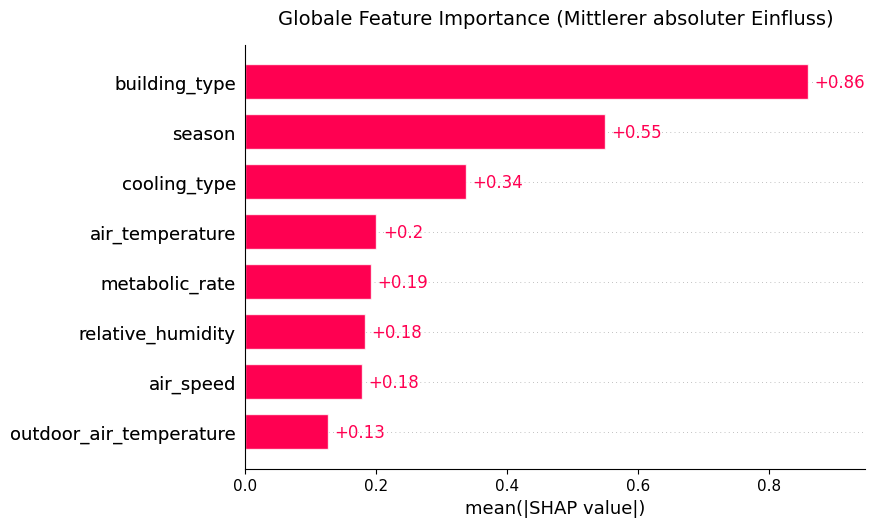

In [24]:
import shap
import matplotlib.pyplot as plt

# klares Balkendiagramm der globalen Wichtigkeit
plt.figure(figsize=(10, 6))

#shap.plots.bar(shap_values_anomaly, show=False)
shap.plots.bar(shap_kombiniert, show=False)

plt.gca().set_title("Globale Feature Importance (Mittlerer absoluter Einfluss)", fontsize=14, pad=15)

plt.show()

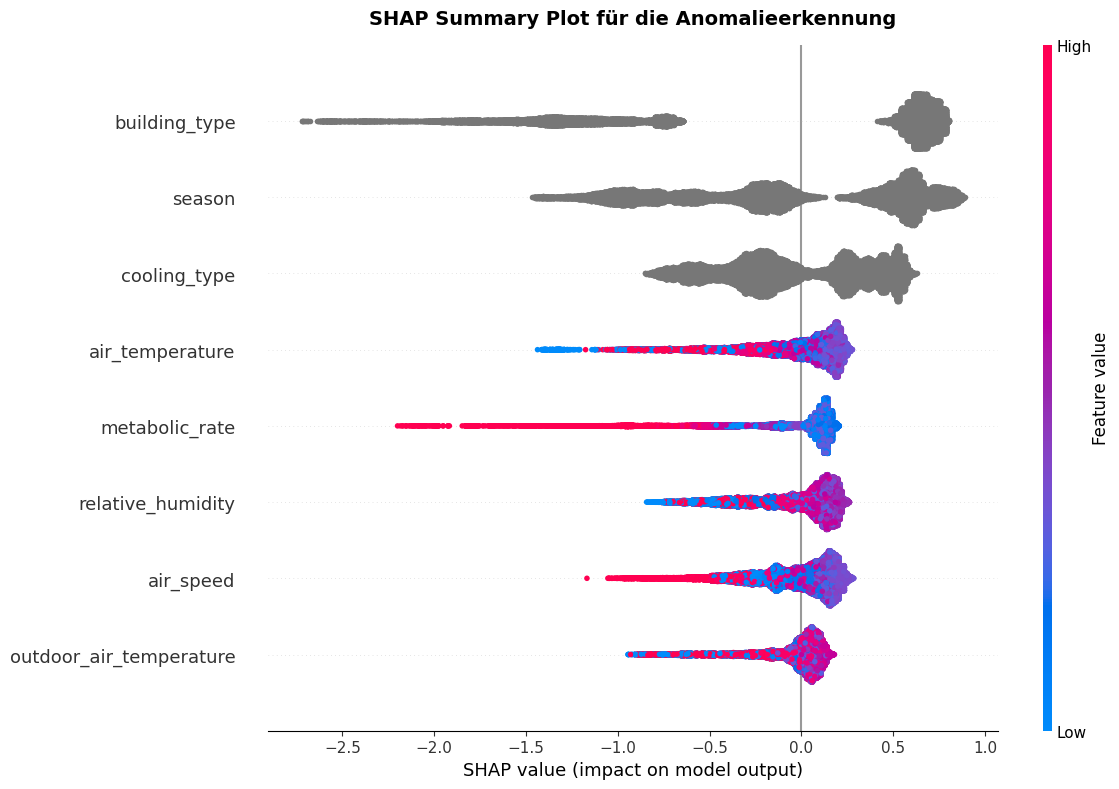

In [25]:
# globaler Summary-Plot
plt.figure(figsize=(12, 8))
#shap.summary_plot(shap_values_anomaly, X_train_preprocessed, feature_names=features_namen, plot_size=None, show=False)
shap.summary_plot(shap_kombiniert, plot_size=None, show=False)

plt.title("SHAP Summary Plot für die Anomalieerkennung", fontsize=14, pad=15, fontweight='bold')

plt.tight_layout()
plt.show()

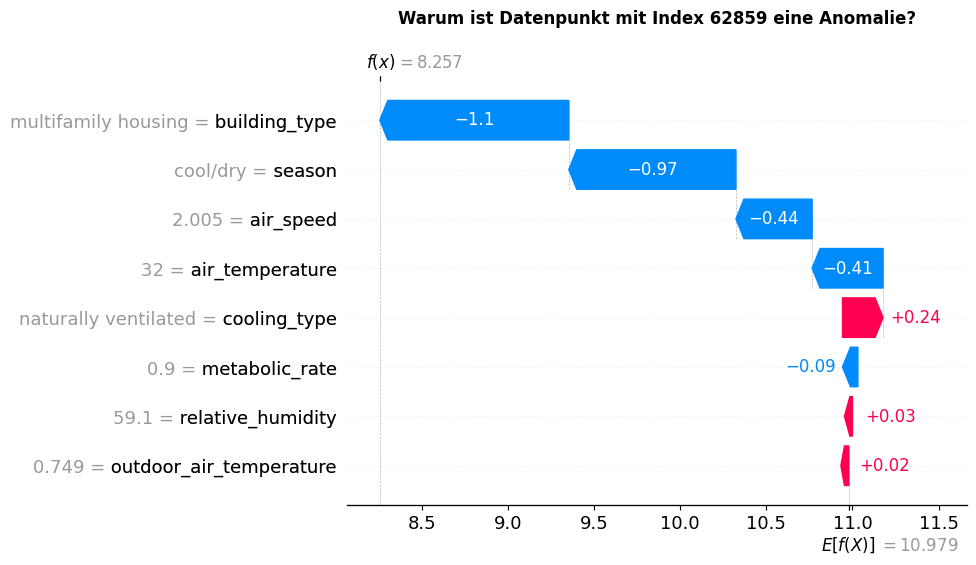

In [26]:
import shap
import matplotlib.pyplot as plt

index = 62859  # ID der Anomalie

#index = 10280

zeilen_pos = X_train_analyzed.index.get_loc(index)

# Wasserfall-Plot
shap.plots.waterfall(shap_kombiniert[zeilen_pos], show=False)

# Titel der Achse setzen
plt.gca().set_title(
    f"Warum ist Datenpunkt mit Index {index} eine Anomalie?", 
    fontsize=12, 
    pad=20, 
    fontweight='bold'
)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_26880\1529417055.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="Einfluss", y="Feature", palette=farben)


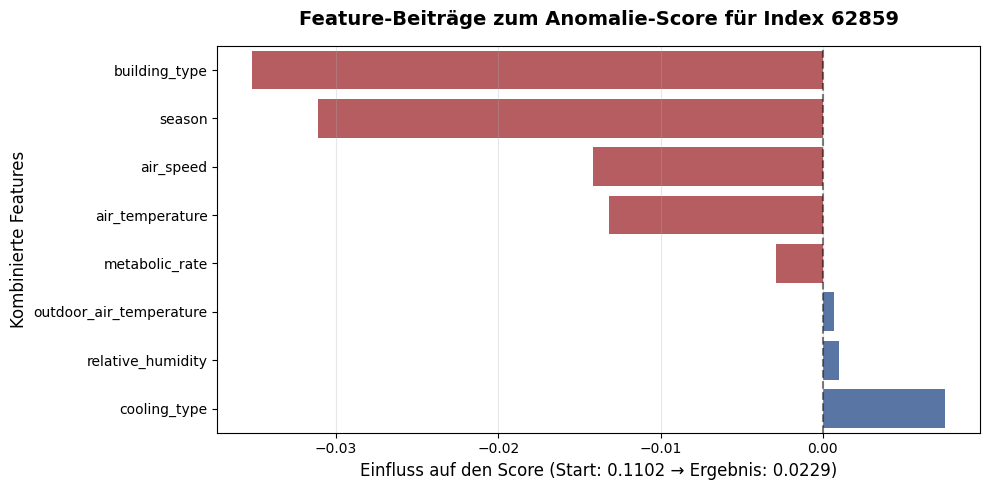

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

wunsch_index = 62859  # Index der Anomalie
zeilen_pos = X_train_analyzed.index.get_loc(wunsch_index)

# echter Anomaliescores für Index
echter_score = X_train_analyzed.loc[wunsch_index, "Anomalie_Score"]
globaler_durchschnitts_score = X_train_analyzed["Anomalie_Score"].mean()

# kombinierter SHAP-Werte für diese eine Zeile
einzel_shap_werte = shap_kombiniert.values[zeilen_pos]
features_namen = shap_kombiniert.feature_names

# Mathematisch faire Skalierung auf das echte Score-Niveau
gesamt_abweichung = echter_score - globaler_durchschnitts_score
summe_shaps = einzel_shap_werte.sum()

# Falls Summe nahe 0 ist, Autteilung gleichmäßig, sonst proportional
if abs(summe_shaps) > 1e-5:
    skalierte_einfluesse = (
        einzel_shap_werte / summe_shaps
    ) * gesamt_abweichung
else:
    skalierte_einfluesse = (
        einzel_shap_werte + (gesamt_abweichung / len(einzel_shap_werte))
    )

# als DataFrame speichern und sortieren
plot_df = pd.DataFrame(
    {"Feature": features_namen, "Einfluss": skalierte_einfluesse}
)
plot_df = plot_df.sort_values(by="Einfluss", ascending=True) # Größte negative Einflüsse nach oben

plt.figure(figsize=(10, 5))

farben = [
    "#C44E52" if x < 0 else "#4C72B0" for x in plot_df["Einfluss"]
]

sns.barplot(data=plot_df, x="Einfluss", y="Feature", palette=farben)

plt.title(
    f"Feature-Beiträge zum Anomalie-Score für Index {wunsch_index}",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel(
    f"Einfluss auf den Score (Start: {globaler_durchschnitts_score:.4f} → Ergebnis: {echter_score:.4f})",
    fontsize=12,
)
plt.ylabel("Kombinierte Features", fontsize=12)

# Eine feine Nulllinie zur Orientierung zeichnen
plt.axvline(x=0, color="black", linestyle="--", alpha=0.5)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Anomalieerkennung für X und y zusammen (noch nicht 100% geprüft!!!)

## Anomalien erkennen

In [28]:
df_combined = df_ml_clo_clean.copy()

#df_combined = df_combined.drop(['season', 'country', 'building_type', 'climate', 'cooling_type'], axis=1)
df_combined = df_combined.drop(['season', 'building_type', 'cooling_type'], axis=1) # alles an kategorische featuren entfernt!!! # die anderen waren eh schon nicht mehr in df_ml_clo_clean

# Keine Aufteilung in X und y oder in train und test

#categorial_features = [
#    "season",
#    "country",
#    "building_type",
#    "cooling_type"
#]

#climate_features = ["climate"]

#columns_to_scale = ['air_speed', 'metabolic_rate']
columns_to_scale = ['air_speed']

# 2. Neuen Preprocessor ohne TargetEncoder definieren
preprocessor_combined = ColumnTransformer(
    transformers=[
        ('power_transform', PowerTransformer(method='yeo-johnson'), columns_to_scale),
        #('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features + climate_features) # climate jetzt hier!
        #('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features) # climate jetzt hier!
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)


In [29]:
anomaly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_combined), 
    ('anomaly_detector', IsolationForest(
        n_estimators=100,
        #contamination=0.02, # Schätzung: 2% Ausreißer
        #contamination=0.00001,  # Minert, muss zwischen 0 und 0.5 liegen offenes Intervall, also exklusive der Randwerte
        #contamination=0.5, # Maxwert
#        contamination=0.013295, # Ausknick bei Kurve ermittelt
        contamination=0.0157355, # Ausknick bei Kurve ermittelt
#        contamination='auto',  #   für ersten Durchlauf zum Ermitteln des richtigen Wertes
        random_state=42,
        n_jobs=-1
    ))
])

# Block angepasst wegen target_encoding
anomaly_pipeline.fit(df_combined)  # y_train wird für das Trainieren ignoriert!!!!    x_train wird über pipeline encoded, y wird aber in der Pipeline benötigt!!!
X_train_preprocessed = anomaly_pipeline.named_steps['preprocessor'].transform(df_combined)  # für spätere plots und zum predicten, xtrain wird umgewandelt und in der Form als dataframe abgespeichert. Es entssteht ein rein numerischer dataframe.

anomaly_scores = anomaly_pipeline.decision_function(df_combined)

df_combined_analyzed = df_combined.copy()
df_combined_analyzed['Anomalie_Score'] = anomaly_scores

df_combined_analyzed['Anomalie_Label'] = anomaly_pipeline.predict(df_combined)

anomalien = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]
print(f"Es wurden {len(anomalien)} Anomalien in den Trainingsdaten identifiziert.")

Es wurden 749 Anomalien in den Trainingsdaten identifiziert.


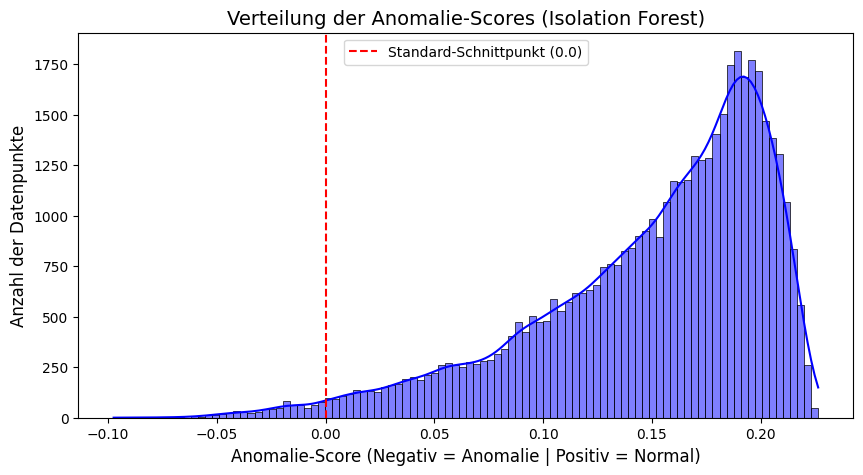

In [30]:
plt.figure(figsize=(10, 5))
# Ein Histogramm mit einer Dichtelinie (KDE) zeichnen
sns.histplot(anomaly_scores, bins=100, kde=True, color='blue')

# Titel und Achsenbeschriftung
plt.title("Verteilung der Anomalie-Scores (Isolation Forest)", fontsize=14)
plt.xlabel("Anomalie-Score (Negativ = Anomalie | Positiv = Normal)", fontsize=12)
plt.ylabel("Anzahl der Datenpunkte", fontsize=12)

# Eine rote Linie bei 0.0 zeichnen (Der Standard-Schwellenwert von Scikit-Learn)
plt.axvline(x=-0.0, color='red', linestyle='--', label='Standard-Schnittpunkt (0.0)')
plt.legend()
plt.show()

# Diese Graphik muss erstmal durch einen ersten Durchlauf des isolation forest erstelle werden. Danach kann man einen contamination-Wert bestimmen.

In [31]:
contamination_wert = (anomaly_scores < -0.093).mean()   # hier Wert eintragen aus Diagramm
print(f"contamination_wert oben für den estimator: {contamination_wert}")


contamination_wert oben für den estimator: 2.101546738399462e-05


# Anomalieerkennung nur Trainset und mit 5 Features

In [32]:
X_train = pd.read_csv('X_train.csv', sep=';')
y_train = pd.read_csv('y_train.csv', sep=';')
df_X = X_train.copy()
df_X['clothing_ensemble_insulation'] = y_train

In [ ]:
df_combined = df_X.copy()

df_combined = df_combined.drop(['season', 'country', 'building_type', 'climate', 'cooling_type'], axis=1)

#categorial_features = [
#    "season",
#    "country",
#    "building_type",
#    "cooling_type"
#]

#climate_features = ["climate"]

#columns_to_scale = ['air_speed', 'metabolic_rate']
columns_to_scale = ['air_speed']

# Preprocessor ohne TargetEncoder
preprocessor_combined = ColumnTransformer(
    transformers=[
        ('power_transform', PowerTransformer(method='yeo-johnson'), columns_to_scale),
        #('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features + climate_features) # climate jetzt hier!
        #('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features) # climate jetzt hier!
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

In [ ]:
anomaly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_combined), 
    ('anomaly_detector', IsolationForest(
        n_estimators=100,
        #contamination=0.02, # Schätzung: 2% Ausreißer
        #contamination=0.00001,  # Minert, muss zwischen 0 und 0.5 liegen offenes Intervall, also exklusive der Randwerte
        #contamination=0.5, # Maxwert
#        contamination=0.013295, # Ausknick bei Kurve ermittelt
        contamination=0.01753, # Ausknick bei Kurve ermittelt
#        contamination='auto',  #   für ersten Durchlauf zum Ermitteln des richtigen Wertes
        random_state=42,
        n_jobs=-1
    ))
])

# Block angepasst wegen target_encoding
anomaly_pipeline.fit(df_combined)  # y_train wird für das Trainieren ignoriert!!!!    x_train wird über pipeline encoded, y wird aber in der Pipeline benötigt!!!
X_train_preprocessed = anomaly_pipeline.named_steps['preprocessor'].transform(df_combined)  # für spätere plots und zum predicten, xtrain wird umgewandelt und in der Form als dataframe abgespeichert. Es entssteht ein rein numerischer dataframe.

anomaly_scores = anomaly_pipeline.decision_function(df_combined)

df_combined_analyzed = df_combined.copy()
df_combined_analyzed['Anomalie_Score'] = anomaly_scores

df_combined_analyzed['Anomalie_Label'] = anomaly_pipeline.predict(df_combined)

anomalien = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]
print(f"Es wurden {len(anomalien)} Anomalien in den Trainingsdaten identifiziert.")


Es wurden 674 Anomalien in den Trainingsdaten identifiziert.


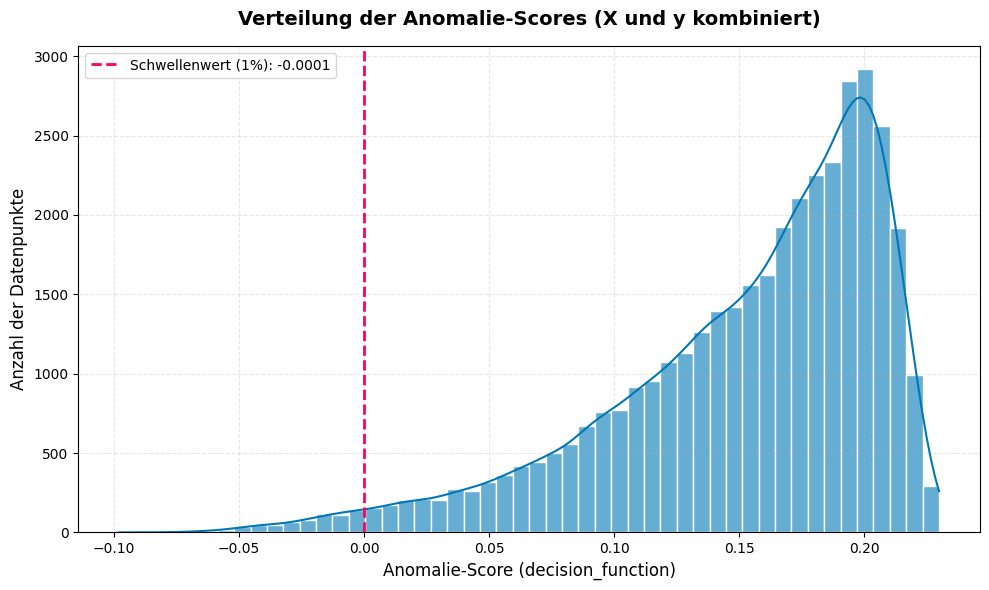

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Histogramm mit Dichtelinie (KDE)
sns.histplot(
    data=df_combined_analyzed, 
    x='Anomalie_Score', 
    kde=True, 
    bins=50, 
    color='#0077B6',
    alpha=0.6,
    edgecolor='white'
)

# Schwellenwert (Threshold) der 3%-Grenze zeichnen
threshold_combined = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]['Anomalie_Score'].max()

plt.axvline(
    x=threshold_combined, 
    color='#FF0055',
    linestyle='--', 
    linewidth=2, 
    label=f'Schwellenwert (1%): {threshold_combined:.4f}'
)


plt.title('Verteilung der Anomalie-Scores (X und y kombiniert)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Anomalie-Score (decision_function)', fontsize=12)
plt.ylabel('Anzahl der Datenpunkte', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

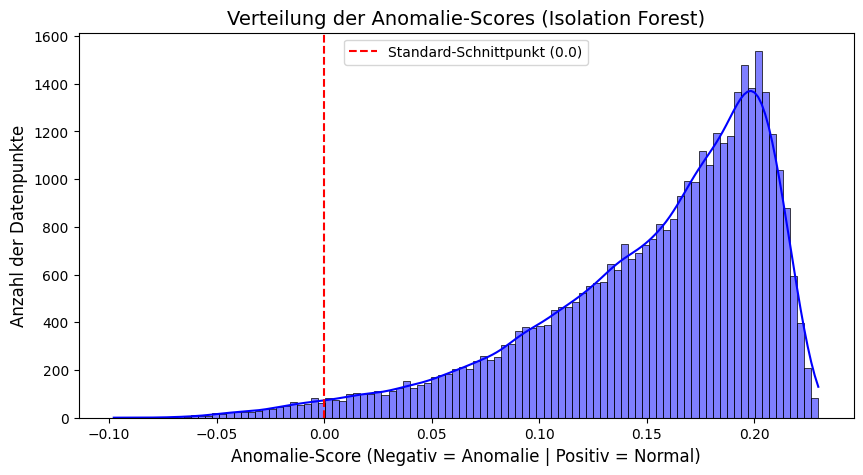

In [ ]:
plt.figure(figsize=(10, 5))
# Ein Histogramm mit einer Dichtelinie (KDE) zeichnen
sns.histplot(anomaly_scores, bins=100, kde=True, color='blue')

plt.title("Verteilung der Anomalie-Scores (Isolation Forest)", fontsize=14)
plt.xlabel("Anomalie-Score (Negativ = Anomalie | Positiv = Normal)", fontsize=12)
plt.ylabel("Anzahl der Datenpunkte", fontsize=12)

# Eine rote Linie bei 0.0 zeichnen (Der Standard-Schwellenwert von Scikit-Learn)
plt.axvline(x=0.0, color='red', linestyle='--', label='Standard-Schnittpunkt (0.0)')
plt.legend()
plt.show()

# Diese Graphik muss erstmal durch einen ersten Durchlauf des isolation forest erstelle werden. Danach kann man einen contamination-Wert bestimmen.

In [37]:
contamination_wert = (anomaly_scores < -0.093).mean()   # hier Wert eintragen aus Diagramm
print(f"contamination_wert oben für den estimator: {contamination_wert}")


contamination_wert oben für den estimator: 2.601795238714713e-05


In [38]:
df_anomaly_train = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]

In [39]:
df_anomaly_train

,outdoor_air_temperature,air_temperature,relative_humidity,air_speed,metabolic_rate,clothing_ensemble_insulation,Anomalie_Score,Anomalie_Label
157,7.700000,20.8,9.6,0.660552,1.006826,1.511510,-0.015304,-1
174,17.604182,21.4,33.1,0.060000,0.800000,2.330000,-0.014122,-1
212,8.700000,24.9,12.7,0.051269,1.006826,1.648920,-0.003765,-1
232,39.400000,36.0,23.2,0.500000,1.000000,0.040000,-0.000100,-1
359,5.700000,18.3,34.5,0.120756,0.767918,1.725834,-0.038117,-1
...,...,...,...,...,...,...,...,...
38136,0.650000,22.3,66.6,0.000000,1.600000,2.290000,-0.043009,-1
38228,-17.450000,19.8,64.4,0.020000,1.200000,2.070000,-0.043343,-1
38262,4.900000,19.5,63.8,0.010000,2.400000,1.700000,-0.035045,-1
38307,4.900000,16.3,52.1,0.020000,0.800000,1.730000,-0.000707,-1


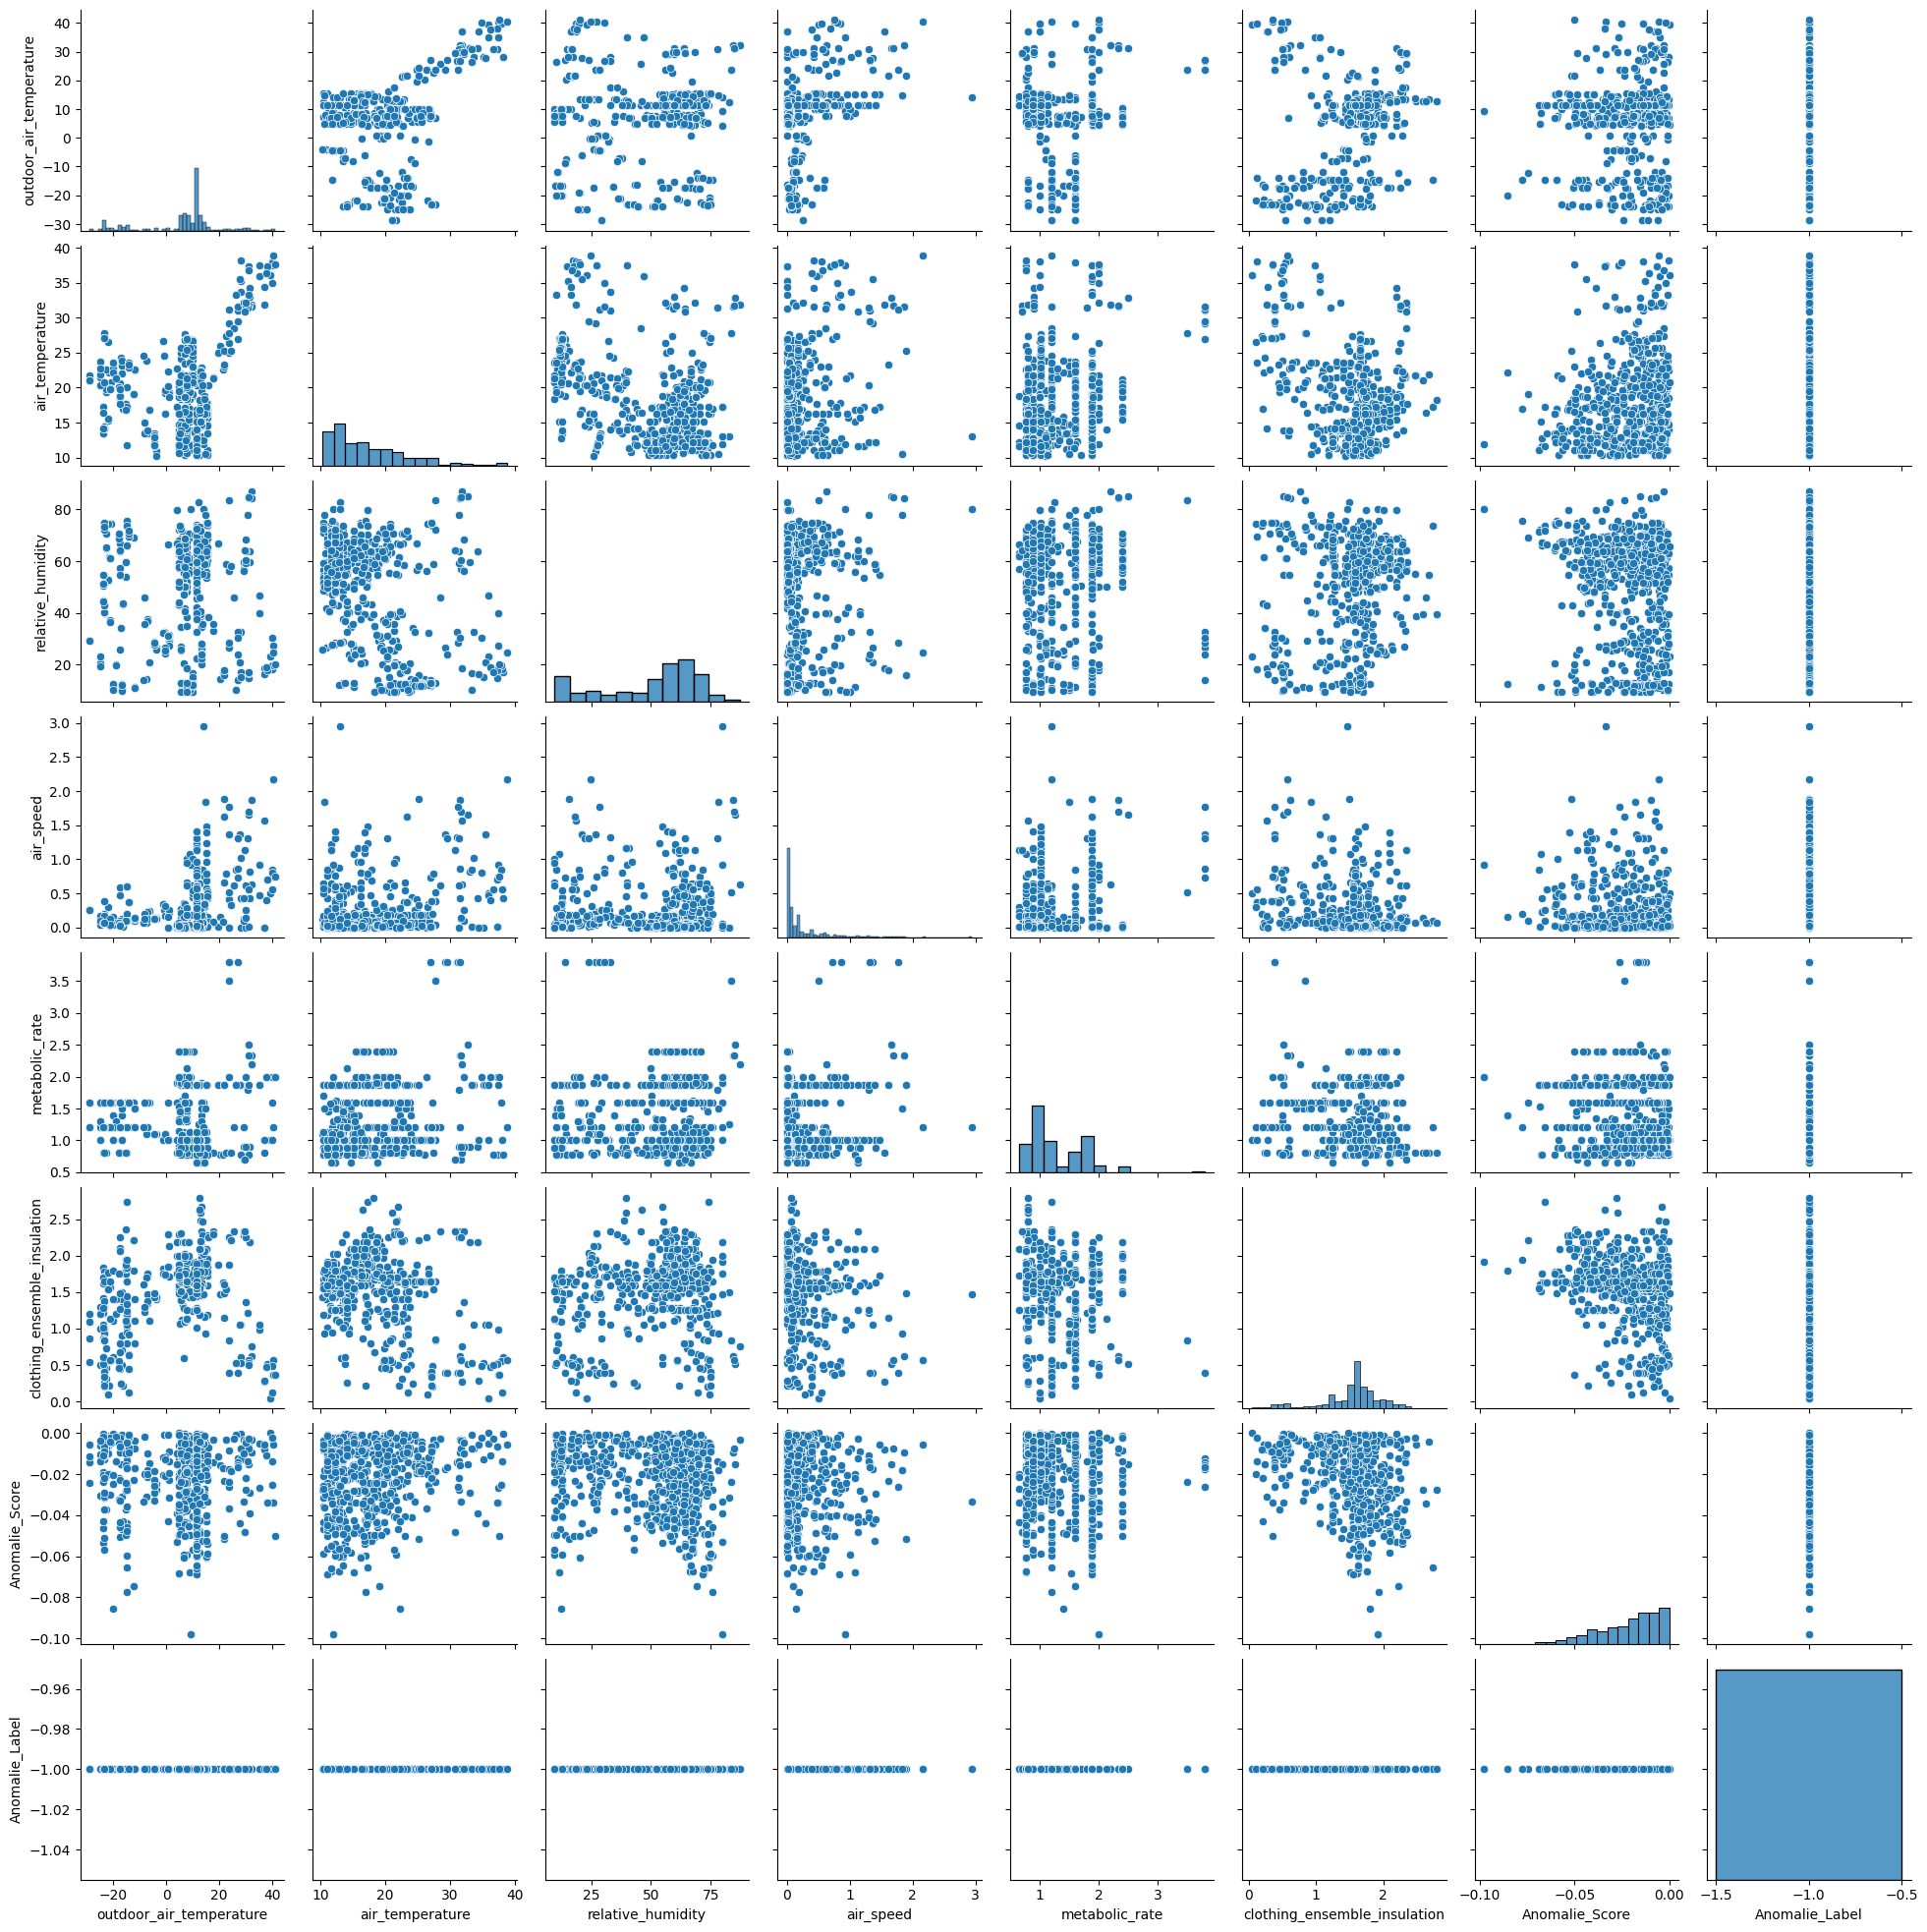

In [40]:
sns.pairplot(data=df_anomaly_train)
plt.show()

## X_test und y_test filtern

### Modell das mit df_X trainiert wurde auf y anwenden zum Anomailien finden

In [41]:
X_test = pd.read_csv('X_test.csv', sep=';')
y_test = pd.read_csv('y_test.csv', sep=';')
df_test_combined = X_test.copy()
df_test_combined['clothing_ensemble_insulation'] = y_test
df_test_combined = df_test_combined.drop(['season', 'country', 'building_type', 'climate', 'cooling_type'], axis=1)

In [42]:
df_test_combined['is_anomaly'] = pipeline_combined.predict(df_test_combined)
#df_test_combined['anomaly_score'] = pipeline_combined.decision_function(df_test_combined)


NameError: name 'pipeline_combined' is not defined

In [ ]:
display(df_test_combined)

In [ ]:
saubere_test_indizes = df_test_combined[df_test_combined['is_anomaly'] == 1].index

X_test_cleaned = X_test.loc[saubere_test_indizes].copy()
y_test_cleaned = y_test.loc[saubere_test_indizes].copy()

# 2. Zur Kontrolle die alten und neuen Dimensionen ausgeben lassen
print(f"Ursprüngliche Zeilenanzahl: {X_test.shape[0]}")
print(f"Bereinigte Zeilenanzahl:    {X_test_cleaned.shape[0]}")
print(f"Gelöschte Anomalien:        {X_test.shape[0] - X_test_cleaned.shape[0]}")

In [ ]:
#X_train_cleaned.to_csv('X_train_cleaned.csv', index=False, sep=';')
#y_train_cleaned.to_csv('y_train_cleaned.csv', index=False, sep=';')

In [ ]:
df_anomaly_test = df_test_combined[df_test_combined['is_anomaly'] == -1]

In [ ]:
display(df_anomaly_test)

In [ ]:
sns.pairplot(data=df_anomaly_test)